In [76]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.13.0+cpu'

In [77]:
weights = 0.7
bias = 0.3

start = 0 
end = 1
step =0.02
x = torch.arange(start,end,step).unsqueeze(dim=1)
y = weights * x + bias

x[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [78]:
train_split = int(0.8 * len(x))
X_train,Y_train = x[:train_split],y[:train_split]
X_test,Y_test = x[train_split:],y[train_split:]

len(X_train),len(Y_train),len(X_test),len(Y_test)

(40, 40, 10, 10)

In [79]:
def plot_prediction(train_data = X_train,
                    train_label = Y_train,
                    test_data = X_test,
                    test_label = Y_test,
                    prediction = None):

    plt.Figure(figsize=(10,7))

    plt.scatter(train_data,train_label,c="b",s=4, label= "training data")
    plt.scatter(test_data,test_label,c="r",s=4, label= "testing data")
    
    if prediction is not None :
        plt.scatter(test_data,prediction,c="g",s=4, label= "training data")

    plt.legend(prop={"size": 8})

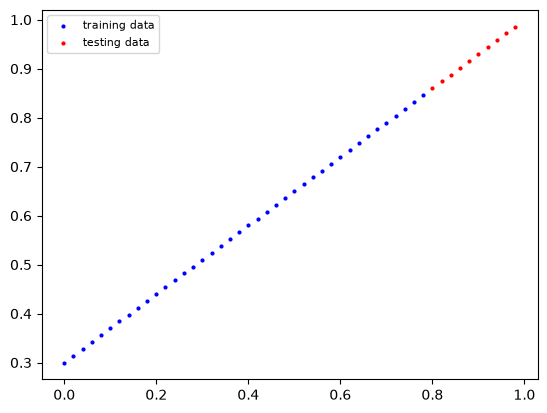

In [80]:
plot_prediction();

In [81]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                            dtype=torch.float),
                                            requires_grad=True)
        
        
        self.bias = nn.Parameter(torch.randn(1,
                                            dtype=torch.float),
                                            requires_grad=True)
        
    def forward(self,X : torch.Tensor) -> torch.Tensor:
        return self.weights * X + self.bias


In [82]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [83]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [84]:
with torch.inference_mode():
    y_pred = model_0(X_test)

In [85]:
len(X_test),len(y_pred)


(10, 10)

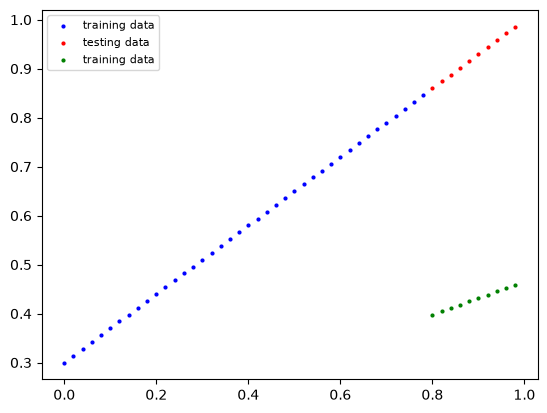

In [86]:
plot_prediction(prediction=y_pred)

In [87]:
loss_func = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

In [88]:
torch.manual_seed(42)

epochs =100

train_loss_value = []
test_loss_value = []
epoch_count = []

for epoch in range(epochs):

    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_func(y_pred,Y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    with torch.inference_mode():

        test_pred = model_0(X_test)

        test_loss = loss_func(test_pred,Y_test.type(torch.float))
        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_value.append(loss.detach().numpy())
            test_loss_value.append(test_loss.detach().numpy())
            print(f"E : {epoch} | MAE TRAIN LOSS : {loss} | MAE TEST LOSS : {test_loss}")


E : 0 | MAE TRAIN LOSS : 0.31288138031959534 | MAE TEST LOSS : 0.48106518387794495
E : 10 | MAE TRAIN LOSS : 0.1976713240146637 | MAE TEST LOSS : 0.3463551998138428
E : 20 | MAE TRAIN LOSS : 0.08908725529909134 | MAE TEST LOSS : 0.21729660034179688
E : 30 | MAE TRAIN LOSS : 0.053148526698350906 | MAE TEST LOSS : 0.14464017748832703
E : 40 | MAE TRAIN LOSS : 0.04543796554207802 | MAE TEST LOSS : 0.11360953003168106
E : 50 | MAE TRAIN LOSS : 0.04167863354086876 | MAE TEST LOSS : 0.09919948130846024
E : 60 | MAE TRAIN LOSS : 0.03818932920694351 | MAE TEST LOSS : 0.08886633068323135
E : 70 | MAE TRAIN LOSS : 0.03476089984178543 | MAE TEST LOSS : 0.0805937647819519
E : 80 | MAE TRAIN LOSS : 0.03132382780313492 | MAE TEST LOSS : 0.07232122868299484
E : 90 | MAE TRAIN LOSS : 0.02788739837706089 | MAE TEST LOSS : 0.06473556160926819


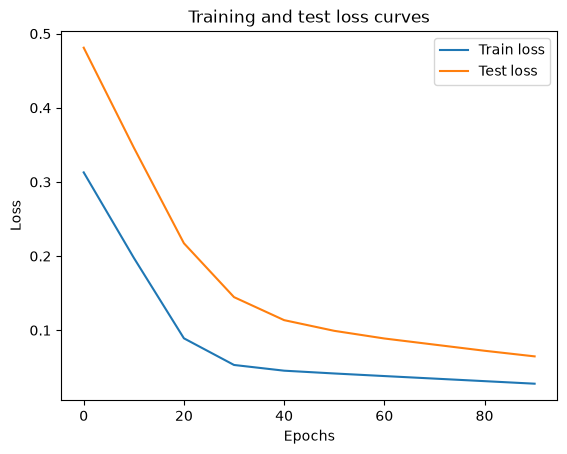

In [89]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_value, label="Train loss")
plt.plot(epoch_count, test_loss_value, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [90]:
model_0.state_dict(),weights,bias

(OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))]),
 0.7,
 0.3)

In [91]:
model_0.eval()
with torch.inference_mode():
    y_pred = model_0(X_test)
y_pred


tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

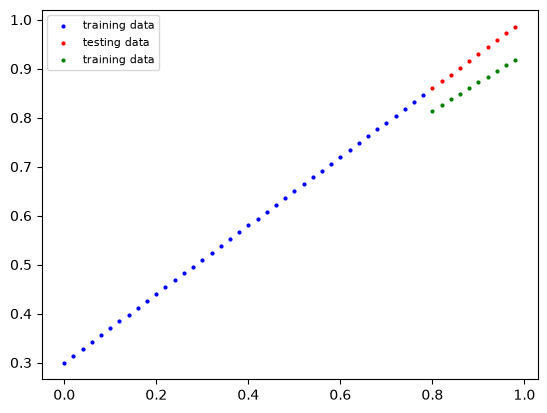

In [92]:
plot_prediction(prediction=y_pred)

In [93]:
from pathlib import Path

model_path = Path("model")
model_path.mkdir(parents=True,exist_ok=True)

model_name = "1stlinearmodel1.pth"
model_save_path = model_path / model_name

torch.save(obj= model_0.state_dict(),f=model_save_path)


In [94]:
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=model_save_path))

<All keys matched successfully>

In [95]:
loaded_model_0.state_dict()

loaded_model_0.eval()

with torch.inference_mode():
    loaded_model_pred = loaded_model_0(X_test)

In [96]:
y_pred == loaded_model_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [97]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.13.0+cpu'

In [98]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [99]:
weight = 0.7
bias = 0.3

start = 0 
end = 1 
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias
x[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [100]:
train_split = int(0.8 * len(X))
X_train,Y_train = X[:train_split],y[:train_split]
X_test,Y_test = X[train_split:],y[train_split:]

len(X_train),len(Y_train),len(X_test),len(Y_test)

(40, 40, 10, 10)

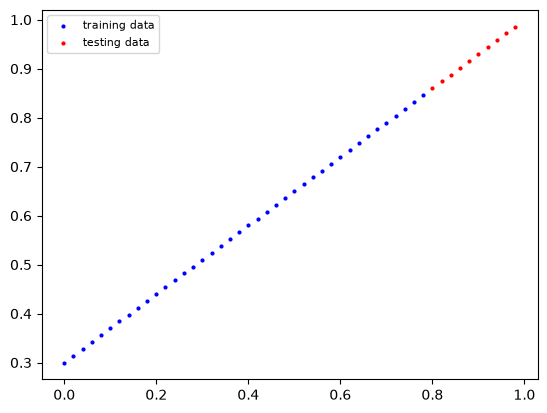

In [101]:
plot_prediction(X_train,Y_train,X_test,Y_test)

In [102]:
class LinearRegressionModelv2(nn.Module):
    def __init__(self):
        super().__init__()
        self.Linear_layer = nn.Linear(in_features=1,
                                      out_features=1)
        
    def forward(self,x : torch.Tensor) -> torch.Tensor:
        return self.Linear_layer(x)
    
torch.manual_seed(42)
model_1 = LinearRegressionModelv2()
model_1,model_1.state_dict()

(LinearRegressionModelv2(
   (Linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('Linear_layer.weight', tensor([[0.7645]])),
              ('Linear_layer.bias', tensor([0.8300]))]))

In [103]:
next(model_1.parameters()).device ,  list(model_1.parameters())

(device(type='cpu'),
 [Parameter containing:
  tensor([[0.7645]], requires_grad=True),
  Parameter containing:
  tensor([0.8300], requires_grad=True)])

In [104]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

In [105]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.01)

In [106]:

torch.manual_seed(42)

epochs = 1000

X_train = X_train.to(device)
X_test = X_test.to(device)
Y_train = Y_train.to(device)
Y_test = Y_test.to(device)

for epoch in range(epochs):
    model_1.train()
    
    y_pred = model_1(X_train)

    loss = loss_fn(y_pred,Y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_1.eval()

    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss=loss_fn(test_pred,Y_test)

    if epoch % 100 == 0 :
        print(f"Epoch: {epoch} | Train loss:{loss} | Testloss :{test_loss}")


Epoch: 0 | Train loss:0.5551779866218567 | Testloss :0.5739762187004089
Epoch: 100 | Train loss:0.006215679459273815 | Testloss :0.014086711220443249
Epoch: 200 | Train loss:0.0012645035749301314 | Testloss :0.013801807537674904
Epoch: 300 | Train loss:0.0012645035749301314 | Testloss :0.013801807537674904
Epoch: 400 | Train loss:0.0012645035749301314 | Testloss :0.013801807537674904
Epoch: 500 | Train loss:0.0012645035749301314 | Testloss :0.013801807537674904
Epoch: 600 | Train loss:0.0012645035749301314 | Testloss :0.013801807537674904
Epoch: 700 | Train loss:0.0012645035749301314 | Testloss :0.013801807537674904
Epoch: 800 | Train loss:0.0012645035749301314 | Testloss :0.013801807537674904
Epoch: 900 | Train loss:0.0012645035749301314 | Testloss :0.013801807537674904


In [107]:
model_1.state_dict(),weight,bias

(OrderedDict([('Linear_layer.weight', tensor([[0.6968]])),
              ('Linear_layer.bias', tensor([0.3025]))]),
 0.7,
 0.3)

In [108]:
model_1.eval()
with torch.inference_mode():
    y_pred = model_1(X_test)

y_pred

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

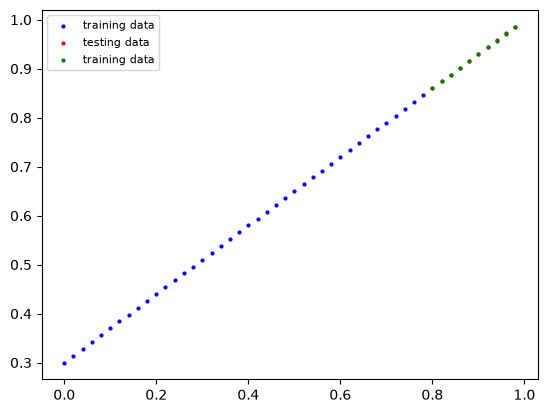

In [109]:
plot_prediction(prediction=y_pred)

In [110]:
from pathlib import Path
model_path = Path("model")
model_path.mkdir(parents=True,exist_ok=True)

model_name = "LinearRegressionModelv2.pth"
model_save_path = model_path / model_name

torch.save(obj=model_1.state_dict(),f=model_save_path)

In [111]:
loaded_model_1 = LinearRegressionModelv2()
loaded_model_1.load_state_dict(torch.load(model_save_path))
loaded_model_1.to(device)
loaded_model_1,next(loaded_model_1.parameters()).device

(LinearRegressionModelv2(
   (Linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 device(type='cpu'))

In [112]:
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_pred = loaded_model_1(X_test)

loaded_model_1_pred == y_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])